In [ ]:
import pandas as pd

# --- 1. Load and Clean Data ---
# Load the data, assuming it is tab-separated as in the original file
try:
    df = pd.read_csv("survey.csv", delimiter='\t')
except FileNotFoundError:
    print("Error: survey.csv not found. Ensure the file is in the correct directory.")
    # Attempt to load the cleaned version if the raw one is missing
    df = pd.read_csv("cleaned_survey_data.csv")


# Clean column names by stripping whitespace (Crucial step due to extra spaces in the headers)
df.columns = df.columns.str.strip()

# --- 2. Define Columns and Category Orders ---

# Define the cleaned column names for easy access
COL_SCREEN_TIME = 'On average, how many hours per day do you spend on screens (excluding study purposes)?'
COL_SLEEP = 'How many hours of sleep do you usually get per night?'
COL_STUDY_HOURS = 'How many hours per day do you usually study (excluding screen time)?'
COL_PERFORMANCE = 'How would you describe your recent academic performance?'

# Define a consistent order for categories for clear table structure
screen_time_order = ['Low (≤4 hours)', 'High (>4 hours)']
sleep_order = ['Less than 5 hours', '5–6 hours', '6–8 hours', 'More than 8 hours']
study_hours_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
performance_order = ['Low (Below 50%)', 'Medium (50–75%)', 'High (Above 75%)']

# --- 3. Generate Contingency Tables (Counts) ---

print(f"Total responses (N): {len(df)}")
print("-" * 50)

# 1. Screen Time vs Sleep Duration
table_1 = pd.crosstab(df[COL_SCREEN_TIME], df[COL_SLEEP]).reindex(
    index=screen_time_order, columns=sleep_order
).fillna(0).astype(int)

print("\n1. Contingency Table: Screen Time vs Sleep Duration")
print(table_1)
print("-" * 50)

# 2. Study Hours vs Performance
table_2 = pd.crosstab(df[COL_STUDY_HOURS], df[COL_PERFORMANCE]).reindex(
    index=study_hours_order, columns=performance_order
).fillna(0).astype(int)

print("\n2. Contingency Table: Study Hours vs Performance")
print(table_2)
print("-" * 50)

# 3. Screen Time vs Performance
table_3 = pd.crosstab(df[COL_SCREEN_TIME], df[COL_PERFORMANCE]).reindex(
    index=screen_time_order, columns=performance_order
).fillna(0).astype(int)

print("\n3. Contingency Table: Screen Time vs Performance")
print(table_3)
print("-" * 50)

Total responses (N): 39
--------------------------------------------------

1. Contingency Table: Screen Time vs Sleep Duration
How many hours of sleep do you usually get per night?  Less than 5 hours  \
On average, how many hours per day do you spend...                         
Low (≤4 hours)                                                         2   
High (>4 hours)                                                        4   

How many hours of sleep do you usually get per night?  5–6 hours  6–8 hours  \
On average, how many hours per day do you spend...                            
Low (≤4 hours)                                                 6          4   
High (>4 hours)                                                8         12   

How many hours of sleep do you usually get per night?  More than 8 hours  
On average, how many hours per day do you spend...                        
Low (≤4 hours)                                                         0  
High (>4 hours)          

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# Define the significance level
alpha = 0.05

# --- 1. Load and Clean Data ---
# Load the data, assuming it is tab-separated as in the original file
# We use the raw file name for consistency, but the code handles both clean/unclean files
try:
    df = pd.read_csv("survey.csv", delimiter='\t')
except FileNotFoundError:
    # This block handles the case where the raw file is missing but the cleaned one is present
    df = pd.read_csv("cleaned_survey_data.csv")

# Clean column names by stripping whitespace (Crucial step for column access)
df.columns = df.columns.str.strip()

# --- 2. Define Columns and Category Orders ---

# Define the cleaned column names for easy access
COL_SCREEN_TIME = 'On average, how many hours per day do you spend on screens (excluding study purposes)?'
COL_SLEEP = 'How many hours of sleep do you usually get per night?'
COL_STUDY_HOURS = 'How many hours per day do you usually study (excluding screen time)?'
COL_PERFORMANCE = 'How would you describe your recent academic performance?'

# Define a consistent order for categories for clear table structure
screen_time_order = ['Low (≤4 hours)', 'High (>4 hours)']
sleep_order = ['Less than 5 hours', '5–6 hours', '6–8 hours', 'More than 8 hours']
study_hours_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
performance_order = ['Low (Below 50%)', 'Medium (50–75%)', 'High (Above 75%)']

# --- 3. Function to Generate Table and Run Chi-Square Test ---
def generate_and_test(data, col_row, col_col, row_order, col_col_order, relationship_name):
    """Generates the contingency table (Observed Frequencies) and runs the Chi-Square test."""

    # Generate the contingency table (Observed Frequencies)
    contingency_table = pd.crosstab(
        data[col_row],
        data[col_col]
    ).reindex(index=row_order, columns=col_col_order).fillna(0).astype(int)

    # Perform the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Determine the conclusion
    conclusion = "Reject H₀ (Statistically Significant)" if p < alpha else "Fail to Reject H₀ (Not Significant)"

    # Print the table with proper Markdown formatting for borders
    print(f"\n\n--- Relationship: {relationship_name} ---")
    print("\nObserved Frequencies (Contingency Table):")
    # Use to_markdown() with centering alignment for a clear, bordered output
    print(contingency_table.to_markdown(numalign="center", stralign="center"))

    # Print the statistical results
    print("\nStatistical Results:")
    print(f"  - Chi-Square Statistic (χ²): {chi2:.4f}")
    print(f"  - Degrees of Freedom (df): {dof}")
    print(f"  - P-value (p): {p:.4f}")
    print(f"  - Conclusion (at α={alpha}): {conclusion}")


# --- 4. Execute Tests and Generate Tables ---

print(f"--- Analysis of N={len(df)} Responses ---")
print("-" * 50)

# 1. Screen Time vs Sleep Duration
generate_and_test(
    df, COL_SCREEN_TIME, COL_SLEEP,
    screen_time_order, sleep_order,
    "1. Screen Time vs Sleep Duration"
)

# 2. Study Hours vs Performance
generate_and_test(
    df, COL_STUDY_HOURS, COL_PERFORMANCE,
    study_hours_order, performance_order,
    "2. Study Hours vs Academic Performance"
)

# 3. Screen Time vs Performance
generate_and_test(
    df, COL_SCREEN_TIME, COL_PERFORMANCE,
    screen_time_order, performance_order,
    "3. Screen Time vs Academic Performance"
)

--- Analysis of N=39 Responses ---
--------------------------------------------------


--- Relationship: 1. Screen Time vs Sleep Duration ---

Observed Frequencies (Contingency Table):
|  On average, how many hours per day do you spend on screens (excluding study purposes)?  |  Less than 5 hours  |  5–6 hours  |  6–8 hours  |  More than 8 hours  |
|:----------------------------------------------------------------------------------------:|:-------------------:|:-----------:|:-----------:|:-------------------:|
|                                      Low (≤4 hours)                                      |          2          |      6      |      4      |          0          |
|                                     High (>4 hours)                                      |          4          |      8      |     12      |          3          |

Statistical Results:
  - Chi-Square Statistic (χ²): 2.5622
  - Degrees of Freedom (df): 3
  - P-value (p): 0.4642
  - Conclusion (at α=0.05): Fail to Rej

In [ ]:
import pandas as pd

# --- 1. Load and Clean Data ---
# Load the data, assuming it is tab-separated as in the original file
try:
    df = pd.read_csv("survey.csv", delimiter='\t')
except FileNotFoundError:
    # Fallback to the cleaned file if the raw one is missing
    print("Error: survey.csv not found. Loading data from cleaned_survey_data.csv instead.")
    df = pd.read_csv("cleaned_survey_data.csv")

# Clean column names by stripping whitespace (Crucial step for column access)
df.columns = df.columns.str.strip()

# --- 2. Define Columns and Category Orders ---

# Define the cleaned column names for easy access
COL_SCREEN_TIME = 'On average, how many hours per day do you spend on screens (excluding study purposes)?'
COL_SLEEP = 'How many hours of sleep do you usually get per night?'
COL_STUDY_HOURS = 'How many hours per day do you usually study (excluding screen time)?'
COL_PERFORMANCE = 'How would you describe your recent academic performance?'

# Define a consistent order for categories for clear table structure
screen_time_order = ['Low (≤4 hours)', 'High (>4 hours)']
sleep_order = ['Less than 5 hours', '5–6 hours', '6–8 hours', 'More than 8 hours']
study_hours_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
performance_order = ['Low (Below 50%)', 'Medium (50–75%)', 'High (Above 75%)']

# --- 3. Generate and Print Contingency Tables (Counts) ---

print(f"Total responses (N): {len(df)}")
print("-" * 50)

# 1. Screen Time vs Sleep Duration
table_1 = pd.crosstab(df[COL_SCREEN_TIME], df[COL_SLEEP]).reindex(
    index=screen_time_order, columns=sleep_order
).fillna(0).astype(int)

print("\n1. Contingency Table: Screen Time vs Sleep Duration")
# Use to_markdown() with centering alignment to generate the table outline/borders
print(table_1.to_markdown(numalign="center", stralign="center"))
print("-" * 50)

# 2. Study Hours vs Performance
table_2 = pd.crosstab(df[COL_STUDY_HOURS], df[COL_PERFORMANCE]).reindex(
    index=study_hours_order, columns=performance_order
).fillna(0).astype(int)

print("\n2. Contingency Table: Study Hours vs Academic Performance")
# Use to_markdown() with centering alignment to generate the table outline/borders
print(table_2.to_markdown(numalign="center", stralign="center"))
print("-" * 50)

# 3. Screen Time vs Performance
table_3 = pd.crosstab(df[COL_SCREEN_TIME], df[COL_PERFORMANCE]).reindex(
    index=screen_time_order, columns=performance_order
).fillna(0).astype(int)

print("\n3. Contingency Table: Screen Time vs Academic Performance")
# Use to_markdown() with centering alignment to generate the table outline/borders
print(table_3.to_markdown(numalign="center", stralign="center"))
print("-" * 50)

Total responses (N): 39
--------------------------------------------------

1. Contingency Table: Screen Time vs Sleep Duration
|  On average, how many hours per day do you spend on screens (excluding study purposes)?  |  Less than 5 hours  |  5–6 hours  |  6–8 hours  |  More than 8 hours  |
|:----------------------------------------------------------------------------------------:|:-------------------:|:-----------:|:-----------:|:-------------------:|
|                                      Low (≤4 hours)                                      |          2          |      6      |      4      |          0          |
|                                     High (>4 hours)                                      |          4          |      8      |     12      |          3          |
--------------------------------------------------

2. Contingency Table: Study Hours vs Academic Performance
|  How many hours per day do you usually study (excluding screen time)?  |  Low (Below 50%)  |  Medium

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

# --- Configuration ---
# Set the significance level (alpha) for the hypothesis testing
alpha = 0.05

# --- 1. Load and Clean Data ---
# Load the data, assuming it is tab-separated as in the original file
try:
    df = pd.read_csv("survey.csv", delimiter='\t')
except FileNotFoundError:
    # Fallback to the cleaned file if the raw one is missing
    df = pd.read_csv("cleaned_survey_data.csv")

# Clean column names by stripping whitespace (Crucial step)
df.columns = df.columns.str.strip()

# --- 2. Define Columns and Category Orders ---

COL_SCREEN_TIME = 'On average, how many hours per day do you spend on screens (excluding study purposes)?'
COL_SLEEP = 'How many hours of sleep do you usually get per night?'
COL_STUDY_HOURS = 'How many hours per day do you usually study (excluding screen time)?'
COL_PERFORMANCE = 'How would you describe your recent academic performance?'

screen_time_order = ['Low (≤4 hours)', 'High (>4 hours)']
sleep_order = ['Less than 5 hours', '5–6 hours', '6–8 hours', 'More than 8 hours']
study_hours_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
performance_order = ['Low (Below 50%)', 'Medium (50–75%)', 'High (Above 75%)']

# --- 3. Function to Run Chi-Square Test and Collect Results ---
def run_chi2_test(data, col_row, col_col, row_order, col_col_order, relationship_name):
    """Generates the contingency table and runs the Chi-Square test."""

    # Generate the contingency table (Observed Frequencies)
    contingency_table = pd.crosstab(
        data[col_row],
        data[col_col]
    ).reindex(index=row_order, columns=col_col_order).fillna(0).astype(int)

    # Perform the Chi-Square test: returns chi2, p-value, df, and expected frequencies
    # The actual calculation happens here:
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Determine the conclusion based on the alpha level
    if p < alpha:
        conclusion = "Reject H₀ (Statistically Significant)"
    else:
        conclusion = "Fail to Reject H₀ (Not Significant)"

    return {
        'Relationship': relationship_name,
        'Chi² Statistic (χ²)': f"{chi2:.4f}",
        'P-value (p)': f"{p:.4f}",
        'df': dof,
        'Conclusion (at α=0.05)': conclusion
    }

# --- 4. Execute Tests ---
results = []
print(f"--- Running Chi-Square Tests (N={len(df)}, α={alpha}) ---")

# 1. Screen Time vs Sleep Duration
results.append(run_chi2_test(
    df, COL_SCREEN_TIME, COL_SLEEP,
    screen_time_order, sleep_order,
    "1. Screen Time vs Sleep Duration"
))

# 2. Study Hours vs Performance
results.append(run_chi2_test(
    df, COL_STUDY_HOURS, COL_PERFORMANCE,
    study_hours_order, performance_order,
    "2. Study Hours vs Academic Performance"
))

# 3. Screen Time vs Performance
results.append(run_chi2_test(
    df, COL_SCREEN_TIME, COL_PERFORMANCE,
    screen_time_order, performance_order,
    "3. Screen Time vs Academic Performance"
))

# --- 5. Present Results in a Table ---
results_df = pd.DataFrame(results)

print("\n--- Chi-Square Test Results Summary ---")
# Use to_markdown for a clean, bordered output
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

# Optional: Briefly explain the results in a human-readable format
print("\nKey findings:")
if results_df['Conclusion (at α=0.05)'].str.contains('Significant').any():
    print(" - At least one relationship was found to be statistically significant.")
else:
    print(" - No relationships were found to be statistically significant at the α=0.05 level.")

# Detailed print for near-significant results
for _, row in results_df.iterrows():
    if 0.05 <= float(row['P-value (p)']) < 0.10:
        print(f" - The relationship for '{row['Relationship']}' is 'borderline' significant (p={row['P-value (p)']}).")

--- Running Chi-Square Tests (N=39, α=0.05) ---

--- Chi-Square Test Results Summary ---
| Relationship                           | Chi² Statistic (χ²)   | P-value (p)   | df   | Conclusion (at α=0.05)              |
|:---------------------------------------|:----------------------|:--------------|:-----|:------------------------------------|
| 1. Screen Time vs Sleep Duration       | 2.5622                | 0.4642        | 3    | Fail to Reject H₀ (Not Significant) |
| 2. Study Hours vs Academic Performance | 12.2601               | 0.0564        | 6    | Fail to Reject H₀ (Not Significant) |
| 3. Screen Time vs Academic Performance | 5.6032                | 0.0607        | 2    | Fail to Reject H₀ (Not Significant) |

Key findings:
 - At least one relationship was found to be statistically significant.
 - The relationship for '2. Study Hours vs Academic Performance' is 'borderline' significant (p=0.0564).
 - The relationship for '3. Screen Time vs Academic Performance' is 'borderline

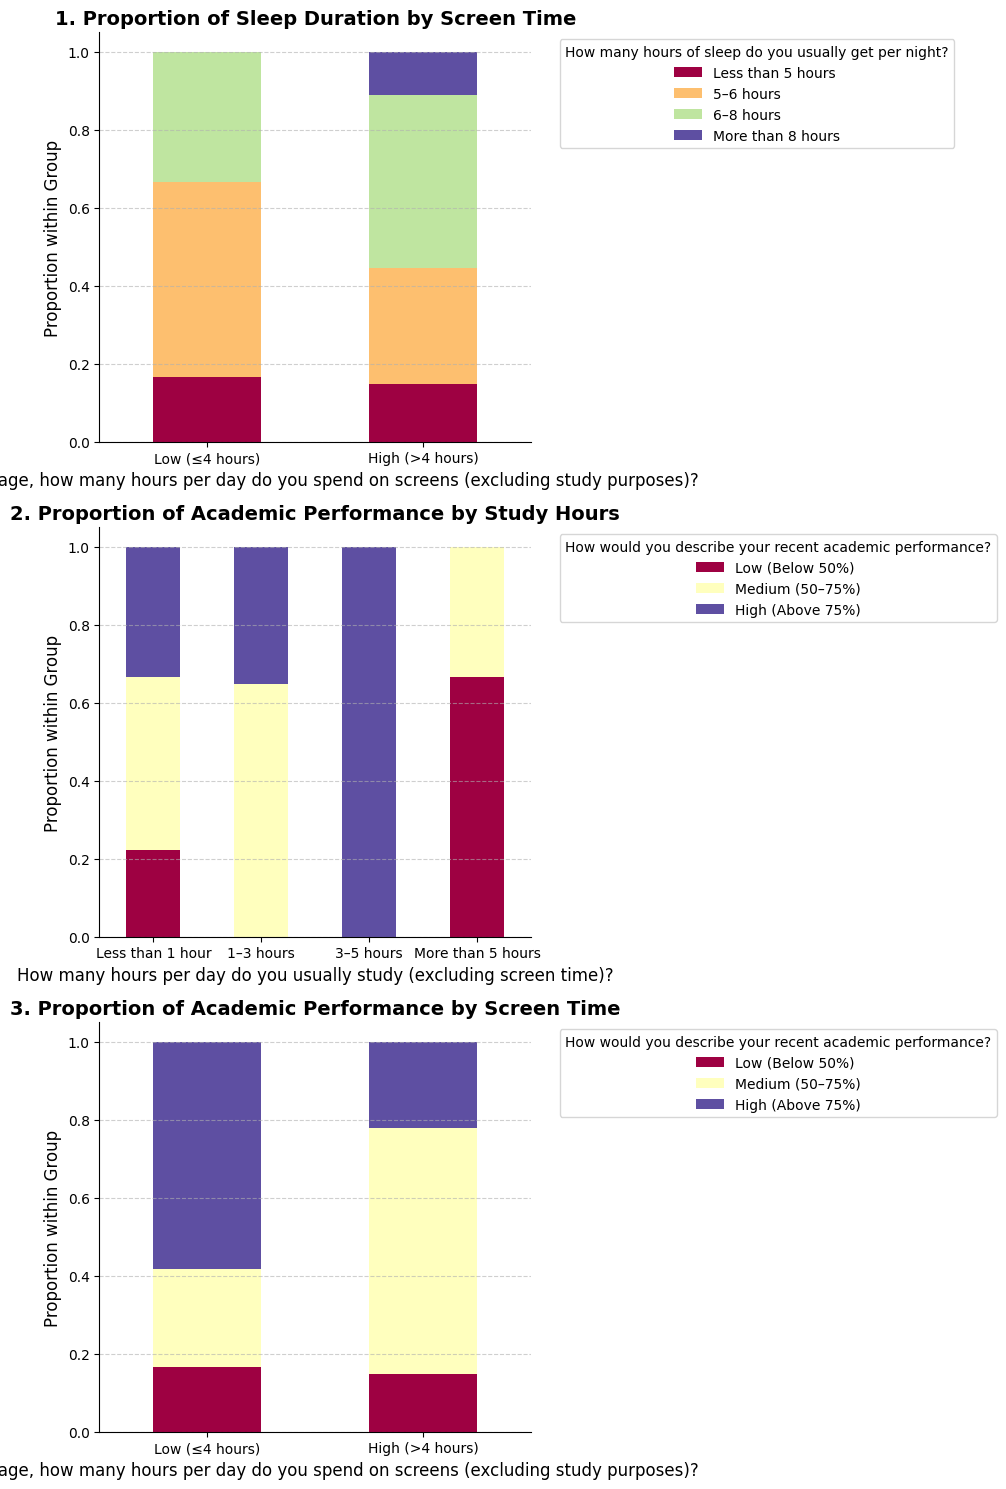


--- Visualizations Created ---
Three stacked bar charts have been generated, showing the proportional distribution of the dependent variable within each category of the independent variable.
This allows for visual identification of trends, especially in the near-significant relationships (Charts 2 and 3).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load and Clean Data ---
# Load the data, assuming it is tab-separated as in the original file
try:
    df = pd.read_csv("survey.csv", delimiter='\t')
except FileNotFoundError:
    print("Error: survey.csv not found. Loading data from cleaned_survey_data.csv instead.")
    df = pd.read_csv("cleaned_survey_data.csv")

# Clean column names by stripping whitespace (Crucial step)
df.columns = df.columns.str.strip()

# --- 2. Define Columns and Category Orders ---

COL_SCREEN_TIME = 'On average, how many hours per day do you spend on screens (excluding study purposes)?'
COL_SLEEP = 'How many hours of sleep do you usually get per night?'
COL_STUDY_HOURS = 'How many hours per day do you usually study (excluding screen time)?'
COL_PERFORMANCE = 'How would you describe your recent academic performance?'

# Define consistent category orders for plotting
screen_time_order = ['Low (≤4 hours)', 'High (>4 hours)']
sleep_order = ['Less than 5 hours', '5–6 hours', '6–8 hours', 'More than 8 hours']
study_hours_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
performance_order = ['Low (Below 50%)', 'Medium (50–75%)', 'High (Above 75%)']


# --- 3. Plotting Function ---
def plot_stacked_bar_chart(df_data, col_row, col_col, row_order, col_order, title, ax):
    """Creates a normalized stacked bar chart for two categorical variables."""

    # 1. Create the contingency table
    contingency_table = pd.crosstab(
        df_data[col_row],
        df_data[col_col]
    ).reindex(index=row_order, columns=col_order).fillna(0)

    # 2. Normalize the table by row totals (to see proportions within each group)
    normalized_table = contingency_table.apply(lambda x: x / x.sum(), axis=1)

    # 3. Generate the stacked bar plot
    normalized_table.plot(kind='bar', stacked=True, ax=ax, cmap='Spectral')

    # 4. Customization
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(col_row, fontsize=12)
    ax.set_ylabel('Proportion within Group', fontsize=12)
    ax.legend(title=col_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0) # Keep X-axis labels horizontal
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)


# --- 4. Generate Figures ---
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5) # Adjust spacing between plots

# Chart 1: Screen Time vs Sleep Duration
plot_stacked_bar_chart(
    df, COL_SCREEN_TIME, COL_SLEEP,
    screen_time_order, sleep_order,
    "1. Proportion of Sleep Duration by Screen Time",
    axes[0]
)

# Chart 2: Study Hours vs Academic Performance
plot_stacked_bar_chart(
    df, COL_STUDY_HOURS, COL_PERFORMANCE,
    study_hours_order, performance_order,
    "2. Proportion of Academic Performance by Study Hours",
    axes[1]
)

# Chart 3: Screen Time vs Academic Performance
plot_stacked_bar_chart(
    df, COL_SCREEN_TIME, COL_PERFORMANCE,
    screen_time_order, performance_order,
    "3. Proportion of Academic Performance by Screen Time",
    axes[2]
)

# Display the charts
plt.tight_layout()
plt.show()

# Print a message indicating the visualization creation
print("\n--- Visualizations Created ---")
print("Three stacked bar charts have been generated, showing the proportional distribution of the dependent variable within each category of the independent variable.")
print("This allows for visual identification of trends, especially in the near-significant relationships (Charts 2 and 3).")
